In this notebook, we try to find the best pretrained backbone for the jaguar reidentification. We try multiple backbones for embedding the jaguar images. After embedding we use a newly trained models using ArcFaceLoss. We compare the identity-based mAP for the validation set, the number of parameters and the training time. The notebooks compares the following backbones:
1. Megadescriptor
2. CLIP
3. DINOv3
4. EfficientNet
5. ResNet18

## 1. Setup and Configuration

In [ ]:
EXPERIMENT_NAME = "backbone2"
RANDOM_SEED = 51

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv

import torch
from torch.utils.data import DataLoader
import numpy as np
from tabulate import tabulate
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    get_embeddings, extract_embeddings,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.criterions import ArcFaceLoss
from src.models import EmbeddingProjection
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.training import train_loop
from src.visualization import visualize_embeddings_mds, plot_history

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 51 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {   
    # MegaDescriptor Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "megadescriptor_input_size": 384,
    
    # Clip Model
    "clip_model": "hf-hub:timm/vit_base_patch16_clip_224.openai",
    "clip_input_size": 224,
    
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,
    
    # EfficientNet Model
    "efficientnet_model": "hf-hub:timm/efficientnet_b0.ra_in1k",
    "efficientnet_input_size": 384,

    # ResNet18 Model
    "resnet18_model": "hf-hub:timm/resnet18.a1_in1k",
    "resnet18_input_size": 224,

    # ArcFace Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  megadescriptor_input_size: 384
  clip_model: hf-hub:timm/vit_base_patch16_clip_224.openai
  clip_input_size: 224
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  efficientnet_model: hf-hub:timm/efficientnet_b0.ra_in1k
  efficientnet_input_size: 384
  resnet18_model: hf-hub:timm/resnet18.a1_in1k
  resnet18_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 51


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


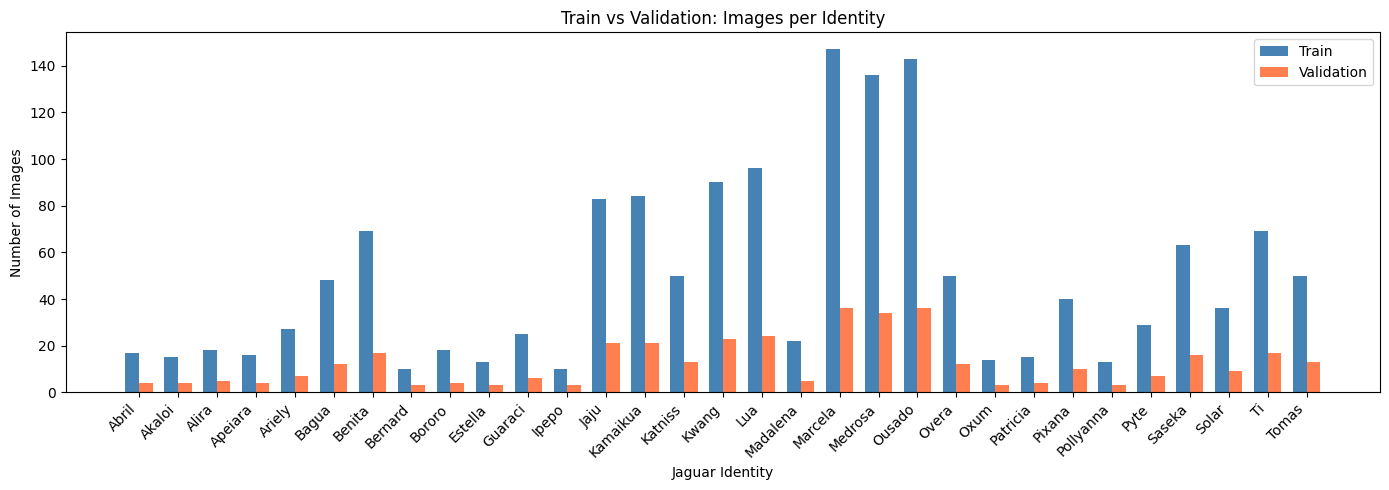


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [ ]:
num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [11]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [ ]:
table = [
    ["Backbone", "Best val_mAP", "Best epoch", "Num params", "Embedding Time"]
]

## Megadescriptor

In [21]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)
megadescriptor.compile()

megadescriptor_config = resolve_data_config({}, model=megadescriptor)
megadescriptor_preprocess = create_transform(**megadescriptor_config, is_training=False)

megadescriptor_num_params = sum(p.numel() for p in megadescriptor.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {megadescriptor_num_params:,}")
print(f"  Preprocessing: {megadescriptor_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = megadescriptor_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

Loading MegaDescriptor-L-384 model...
Model loaded successfully
  Parameters: 195,198,516
  Preprocessing: {'input_size': [3, 384, 384], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.9, 'crop_mode': 'center'}
  Embedding dimension: 1536


In [ ]:
megadescriptor_dataset = BlurImageDataset(image_paths, megadescriptor_preprocess)
megadescriptor_loader = DataLoader(
    megadescriptor_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
)

print(f"MegaDescriptor DataLoader created with {len(megadescriptor_loader)} batches")

MegaDescriptor DataLoader created with 60 batches


In [ ]:
megadescriptor_cache_path = OUTPUT_PATH_SHARED / "megadescriptor_blur_embeddings.npz"

megadescriptor_embeddings = get_embeddings(
    megadescriptor,
    megadescriptor_cache_path,
    megadescriptor_loader
)

Extracting embeddings for 60 images...


Extracting embeddings: 100%|██████████| 60/60 [11:14<00:00, 11.25s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2/embeddings/megadescriptor_embeddings.npz
Embeddings shape: (1895, 1536)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


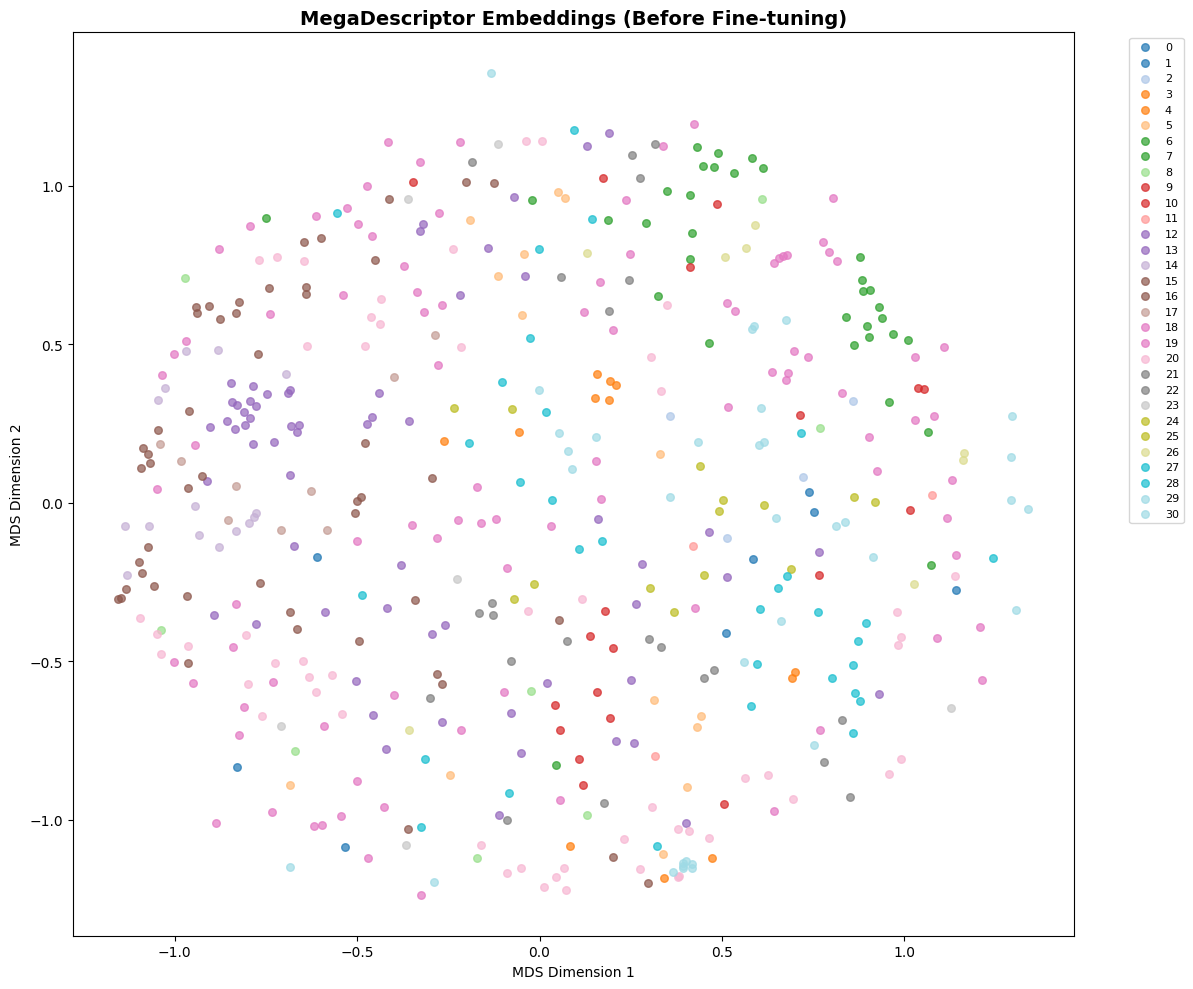

In [24]:
# Visualize MegaDescriptor embeddings
labels = np.array(labels)
fig = visualize_embeddings_mds(
    megadescriptor_embeddings,
    labels,
    "MegaDescriptor Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "megadescriptor_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"megadescriptor_embeddings_mds": wandb.Image(fig)})

In [ ]:
megadescriptor_emb_train_dataset = EmbeddingDataset(
    megadescriptor_embeddings[train_mask],
    train_labels
)

megadescriptor_emb_val_dataset = EmbeddingDataset(
    megadescriptor_embeddings[~train_mask],
    val_labels
)

megadescriptor_emb_train_loader = create_deterministic_training_dataloader(
    megadescriptor_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
)
megadescriptor_emb_val_loader = DataLoader(
    megadescriptor_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [ ]:
# Create model
model = EmbeddingProjection(
    input_dim=megadescriptor_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

  Total parameters: 927,744


In [ ]:
# Setup training components
criterion = ArcFaceLoss(
    embedding_dim=megadescriptor_dim,
    num_classes=num_classes,
    margin=config['arcface_margin'],
    scale=config['arcface_scale']
)

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

optimizer = torch.optim.AdamW(
    list(model.parameters(), criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_megadescriptor_arcface.pth"
history, best_map_duplicated, best_epoch = train_loop(
    model, 
    megadescriptor_emb_train_loader, 
    megadescriptor_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="megadescriptor",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_megadescriptor": best_map_duplicated,
    "best_epoch_megadescriptor": best_epoch,
    "total_epochs_megadescriptor": len(history['train_loss']),
})

table.append([
    "MegaDescriptor",
    best_map_duplicated,
    best_epoch,
    megadescriptor_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 36.6580 | Train Acc: 0.0%
  Val Loss:   33.0216 | Val Acc:   0.0%
  Val mAP:    0.2796 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.2542 | Train Acc: 0.0%
  Val Loss:   28.8436 | Val Acc:   1.3%
  Val mAP:    0.3031 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.0454 | Train Acc: 0.7%
  Val Loss:   25.5196 | Val Acc:   3.4%
  Val mAP:    0.3183 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.1953 | Train Acc: 95.8%
  Val Loss:   4.4856 | Val Acc:   84.2%
  Val mAP:    0.7901 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 85/200


  Train Loss: 0.2399 | Train Acc: 95.1%
  Val Loss:   4.5322 | Val Acc:   83.4%
  Val mAP:    0.7931 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 86/200


  Train Loss: 0.1969 | Train Acc: 95.5%
  Val Loss:   4.5007 | Val Acc:   83.6%
  Val mAP:    0.7904 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 87/200


  Train Loss: 0.1473 | Train Acc: 96.2%
  Val Loss:   4.5027 | Val Acc:   84.4%
  Val mAP:    0.7898 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 88/200


  Train Loss: 0.1680 | Train Acc: 96.0%
  Val Loss:   4.4915 | Val Acc:   84.4%
  Val mAP:    0.7897 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 88 epochs

Training complete!
Best epoch: 78 (Val Loss: 4.4492, Val mAP: 0.7910)


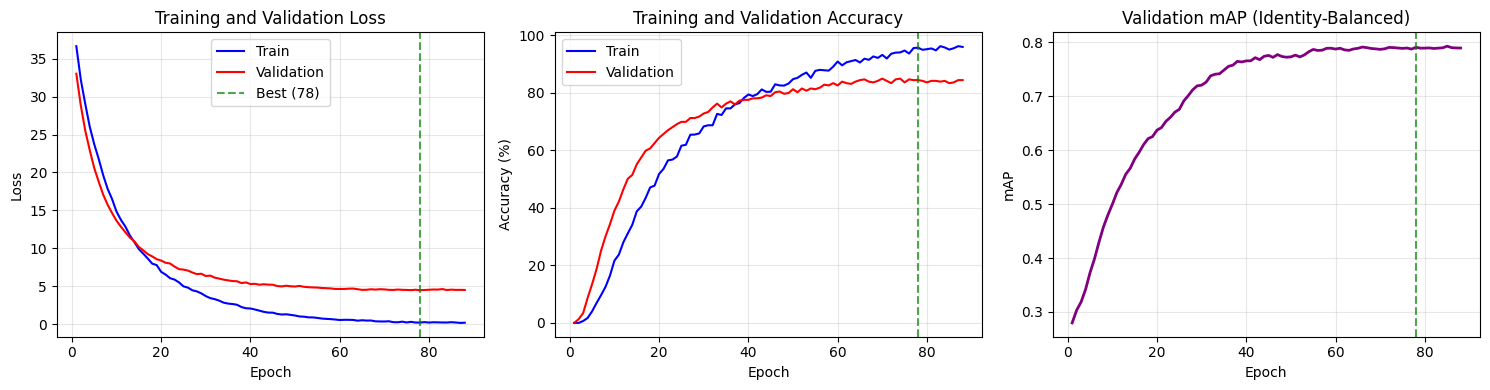

In [29]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_megadescriptor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_megadescriptor": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2
  Val Loss: 4.4492
  Val mAP: 0.7910


In [ ]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(megadescriptor_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


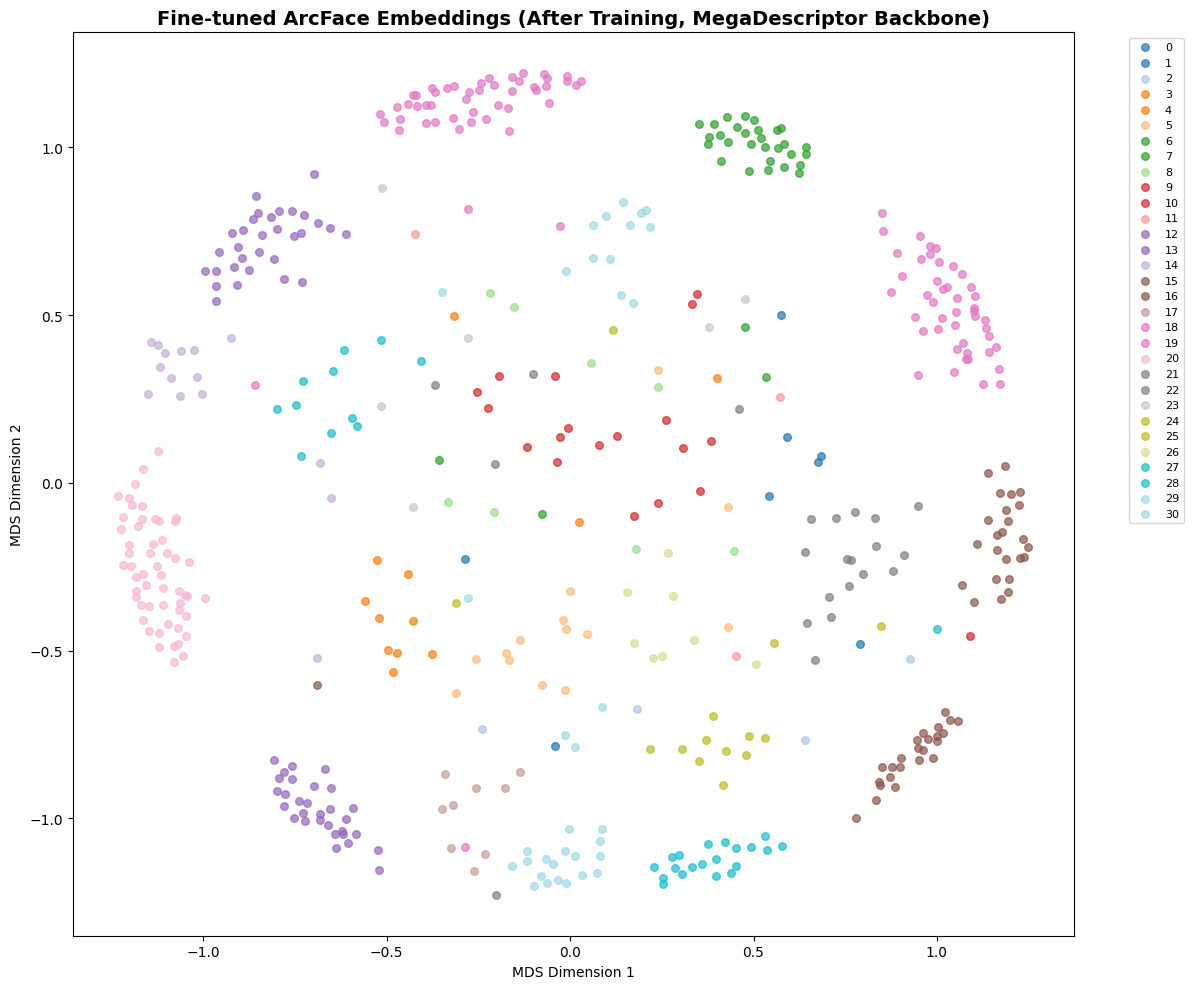

In [32]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, MegaDescriptor Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "megadescriptor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_megadescriptor": wandb.Image(fig_finetuned)})

In [33]:
del megadescriptor_dataset, megadescriptor_loader, megadescriptor_emb_train_dataset, megadescriptor_emb_val_dataset
del model, optimizer, scheduler, history
del megadescriptor, megadescriptor_preprocess, megadescriptor_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## CLIP

In [34]:
# Load CLIP model
print("Loading CLIP model...")
clip = timm.create_model(
    config["clip_model"],
    pretrained=True
)
clip.eval()
clip.to(device)
clip.compile()

clip_config = resolve_data_config({}, model=clip)
clip_preprocess = create_transform(**clip_config, is_training=False)

clip_num_params = sum(p.numel() for p in clip.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {clip_num_params:,}")
print(f"  Preprocessing: {clip_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = clip_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = clip(dummy_input)
    clip_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {clip_dim}")

Loading CLIP model...
Model loaded successfully
  Parameters: 86,193,152
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.48145466, 0.4578275, 0.40821073], 'std': [0.26862954, 0.26130258, 0.27577711], 'crop_pct': 0.9, 'crop_mode': 'center'}
  Embedding dimension: 512


In [ ]:
clip_dataset = BlurImageDataset(image_paths, clip_preprocess)
clip_loader = DataLoader(
    clip_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"CLIP DataLoader created with {len(clip_loader)} batches")

CLIP DataLoader created with 60 batches


In [ ]:
clip_cache_path = OUTPUT_PATH_SHARED / "clip_blur_embeddings.npz"

clip_embeddings = get_embeddings(
    clip,
    clip_cache_path,
    clip_loader
)

Extracting embeddings for 60 images...


Extracting embeddings: 100%|██████████| 60/60 [10:35<00:00, 10.60s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2/embeddings/clip_embeddings.npz
Embeddings shape: (1895, 512)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


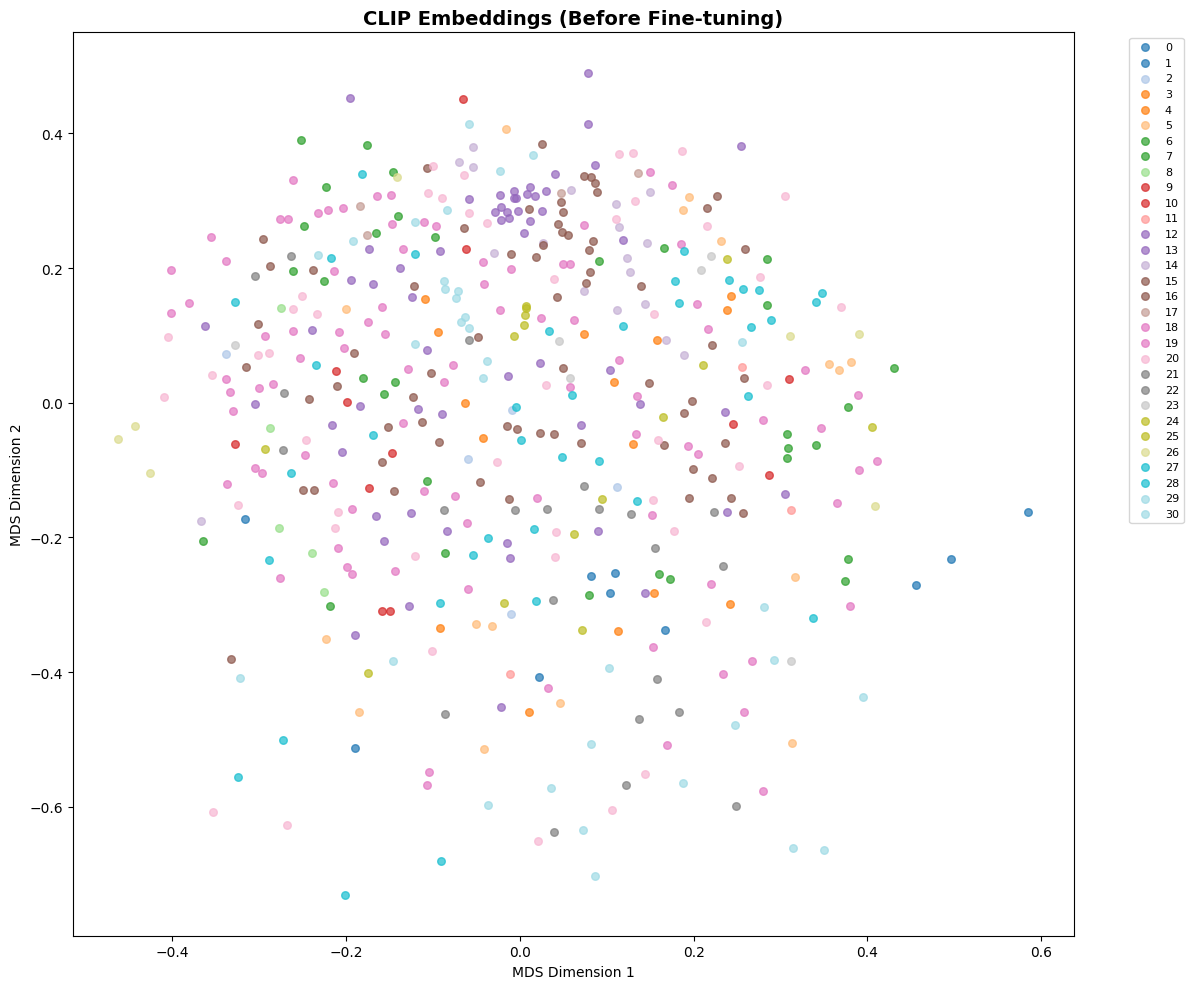

In [37]:
# Visualize CLIP embeddings
fig = visualize_embeddings_mds(
    clip_embeddings,
    labels,
    "CLIP Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "clip_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"clip_embeddings_mds": wandb.Image(fig)})

In [ ]:
clip_emb_train_dataset = EmbeddingDataset(
    clip_embeddings[train_mask],
    train_labels
)

clip_emb_val_dataset = EmbeddingDataset(
    clip_embeddings[~train_mask],
    val_labels
)

clip_emb_train_loader = create_deterministic_training_dataloader(
    clip_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
)
clip_emb_val_loader = DataLoader(
    clip_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [ ]:
# Create model
model = EmbeddingProjection(
    input_dim=clip_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

  Total parameters: 403,456


In [ ]:
# Setup training components
criterion = ArcFaceLoss(
    embedding_dim=clip_dim,
    num_classes=num_classes,
    margin=config['arcface_margin'],
    scale=config['arcface_scale']
)

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

optimizer = torch.optim.AdamW(
    list(model.parameters(), criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_clip_arcface.pth"
history, best_map, best_epoch = train_loop(
    model, 
    clip_emb_train_loader, 
    clip_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="clip",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_clip": best_map_duplicated,
    "best_epoch_clip": best_epoch,
    "total_epochs_clip": len(history['train_loss']),
})

table.append([
    "CLIP",
    best_map,
    best_epoch,
    clip_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s, loss=38.8336, acc=0.0%]

  Train Loss: 37.1595 | Train Acc: 0.0%
  Val Loss:   34.1775 | Val Acc:   0.0%
  Val mAP:    0.2461 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 34.1829 | Train Acc: 0.0%
  Val Loss:   31.4380 | Val Acc:   0.0%
  Val mAP:    0.2532 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 31.9717 | Train Acc: 0.0%
  Val Loss:   29.1294 | Val Acc:   0.0%
  Val mAP:    0.2663 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.4389 | Train Acc: 91.0%
  Val Loss:   5.1726 | Val Acc:   76.0%
  Val mAP:    0.7829 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 130/200


  Train Loss: 0.3726 | Train Acc: 92.2%
  Val Loss:   5.1948 | Val Acc:   75.5%
  Val mAP:    0.7827 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 131/200


  Train Loss: 0.3432 | Train Acc: 92.0%
  Val Loss:   5.2103 | Val Acc:   76.0%
  Val mAP:    0.7797 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 132/200


  Train Loss: 0.4115 | Train Acc: 91.6%
  Val Loss:   5.1410 | Val Acc:   76.0%
  Val mAP:    0.7832 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 133/200


  Train Loss: 0.4305 | Train Acc: 91.7%
  Val Loss:   5.1246 | Val Acc:   75.7%
  Val mAP:    0.7795 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 133 epochs

Training complete!
Best epoch: 123 (Val Loss: 5.0859, Val mAP: 0.7742)


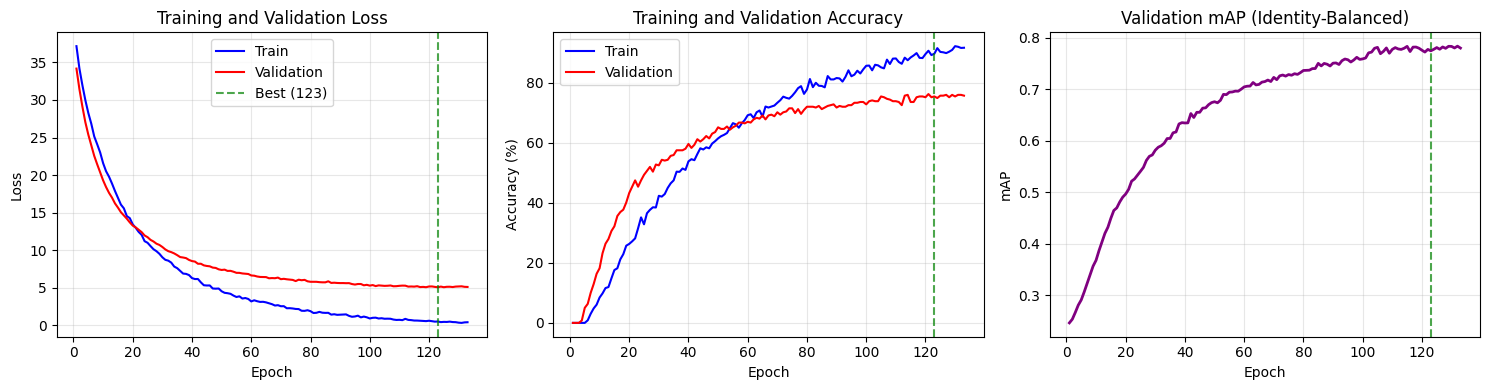

In [42]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_clip.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_clip": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2
  Val Loss: 5.0859
  Val mAP: 0.7742


In [ ]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(clip_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


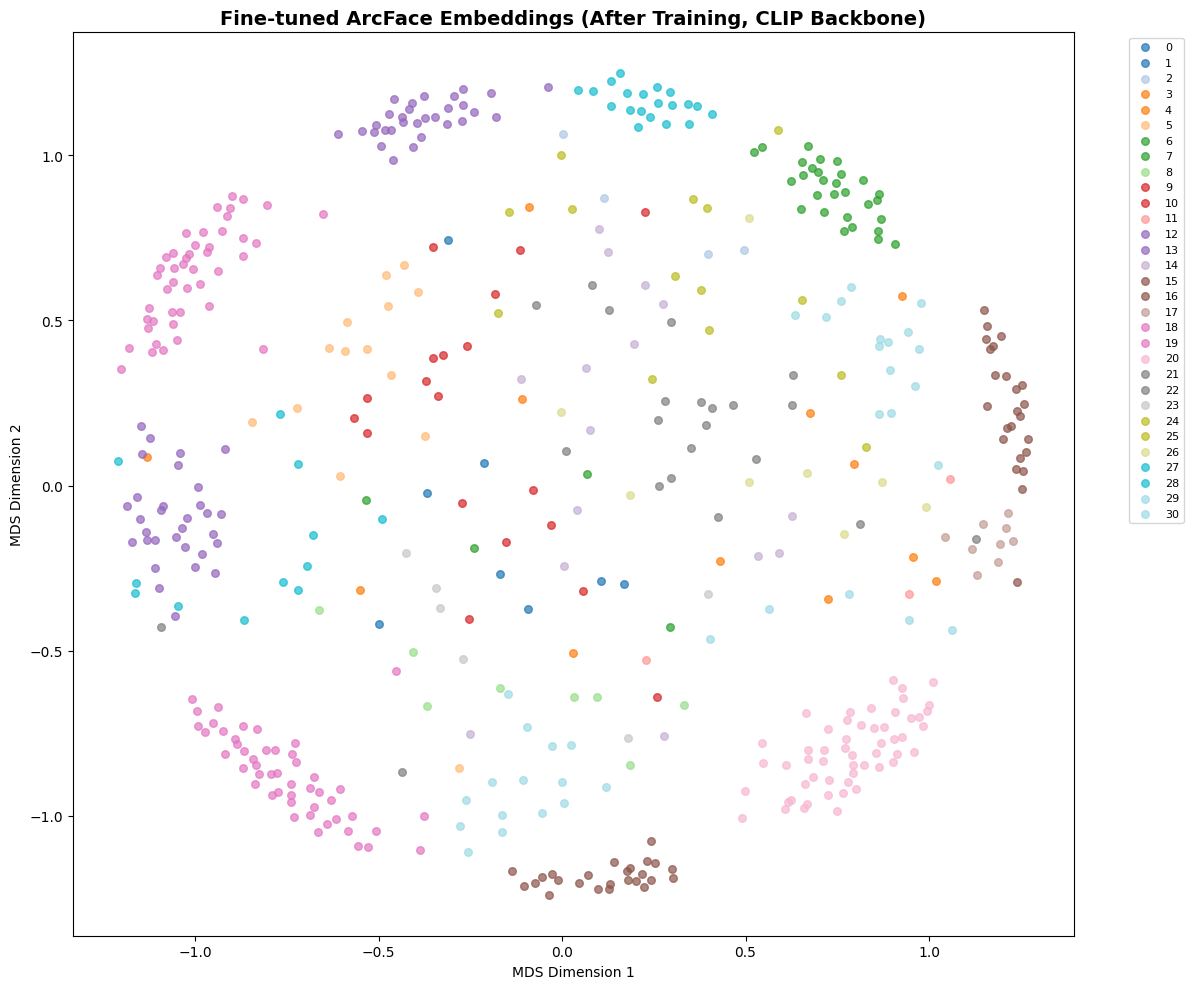

In [45]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, CLIP Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "clip_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_clip": wandb.Image(fig_finetuned)})

In [46]:
del clip_dataset, clip_loader, clip_emb_train_dataset, clip_emb_val_dataset
del model, optimizer, scheduler, history
del clip, clip_preprocess, clip_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## Dinov3

In [47]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [ ]:
dino_dataset = BlurImageDataset(image_paths, dino_preprocess)
dino_loader = DataLoader(
    dino_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"Dino DataLoader created with {len(dino_loader)} batches")

Dino DataLoader created with 60 batches


In [ ]:
dino_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

dino_embeddings = get_embeddings(
    dino,
    dino_cache_path,
    dino_loader
)

Extracting embeddings for 60 images...


Extracting embeddings: 100%|██████████| 60/60 [10:37<00:00, 10.62s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2/embeddings/dino_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


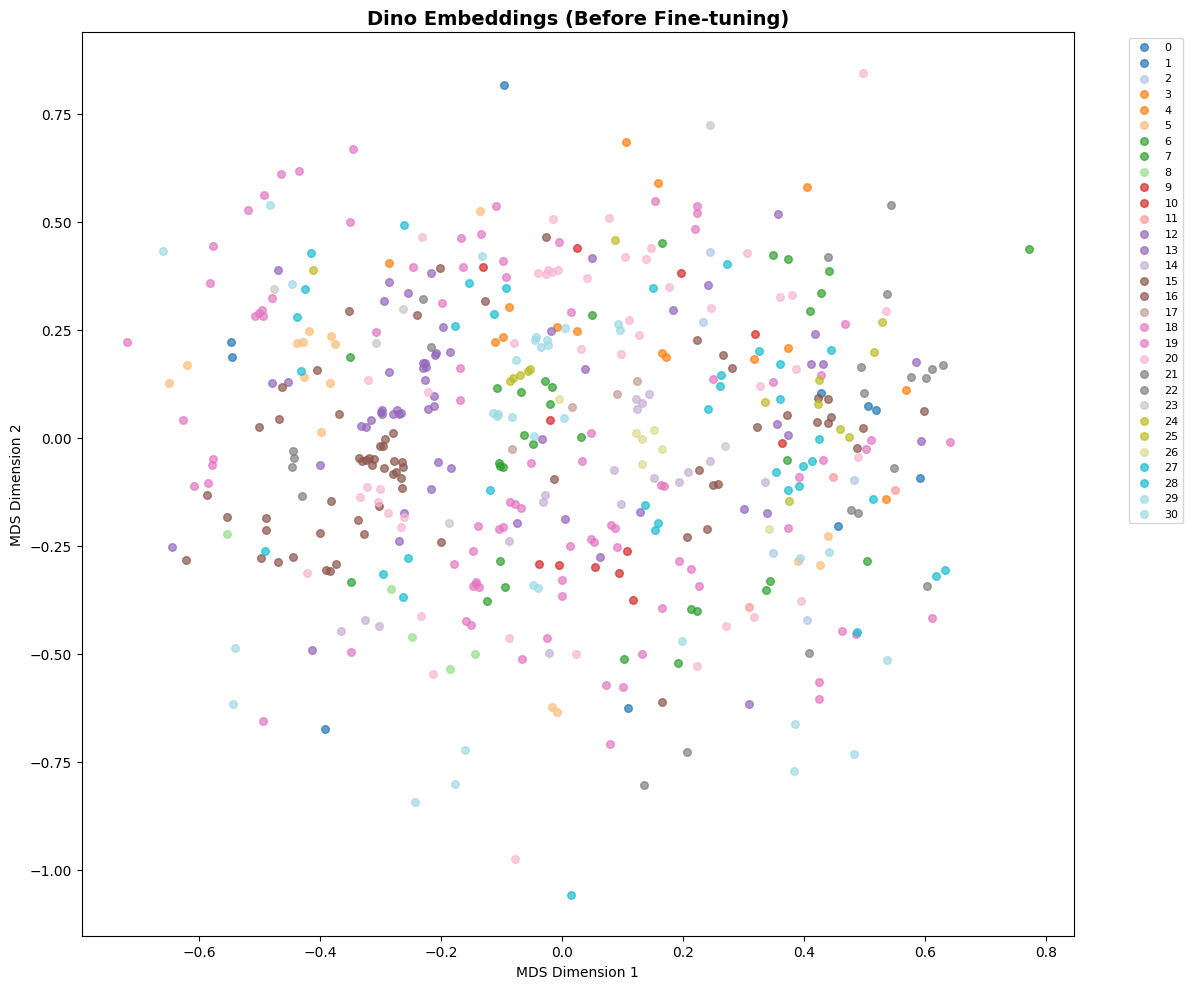

In [50]:
# Visualize Dino embeddings
fig = visualize_embeddings_mds(
    dino_embeddings,
    labels,
    "Dino Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "dino_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"dino_embeddings_mds": wandb.Image(fig)})

In [ ]:
dino_emb_train_dataset = EmbeddingDataset(
    dino_embeddings[train_mask],
    train_labels
)

dino_emb_val_dataset = EmbeddingDataset(
    dino_embeddings[~train_mask],
    val_labels
)

dino_emb_train_loader = create_deterministic_training_dataloader(
    dino_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
)
dino_emb_val_loader = DataLoader(
    dino_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [ ]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

  Total parameters: 534,528


In [ ]:
# Setup training components
criterion = ArcFaceLoss(
    embedding_dim=megadescriptor_dim,
    num_classes=num_classes,
    margin=config['arcface_margin'],
    scale=config['arcface_scale']
)

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

optimizer = torch.optim.AdamW(
    list(model.parameters(), criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_dino_arcface.pth"
history, best_map_duplicated, best_epoch = train_loop(
    model, 
    dino_emb_train_loader, 
    dino_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="dino",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_dino": best_map_duplicated,
    "best_epoch_dino": best_epoch,
    "total_epochs_dino": len(history['train_loss']),
})

table.append([
    "Dino",
    best_map_duplicated,
    best_epoch,
    dino_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s, loss=39.0379, acc=0.0%]

  Train Loss: 36.5401 | Train Acc: 0.0%
  Val Loss:   32.5275 | Val Acc:   0.0%
  Val mAP:    0.3267 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 31.9165 | Train Acc: 0.0%
  Val Loss:   27.9607 | Val Acc:   0.5%
  Val mAP:    0.3420 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.6150 | Train Acc: 0.2%
  Val Loss:   24.5392 | Val Acc:   5.8%
  Val mAP:    0.3625 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.1695 | Train Acc: 95.6%
  Val Loss:   3.2889 | Val Acc:   88.4%
  Val mAP:    0.8460 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 101/200


  Train Loss: 0.2058 | Train Acc: 95.1%
  Val Loss:   3.2913 | Val Acc:   88.7%
  Val mAP:    0.8440 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 102/200


  Train Loss: 0.2024 | Train Acc: 95.1%
  Val Loss:   3.2514 | Val Acc:   88.4%
  Val mAP:    0.8454 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 103/200


  Train Loss: 0.1772 | Train Acc: 95.8%
  Val Loss:   3.2802 | Val Acc:   88.7%
  Val mAP:    0.8456 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 104/200


  Train Loss: 0.1711 | Train Acc: 96.4%
  Val Loss:   3.2656 | Val Acc:   87.9%
  Val mAP:    0.8446 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 104 epochs

Training complete!
Best epoch: 94 (Val Loss: 3.2464, Val mAP: 0.8433)


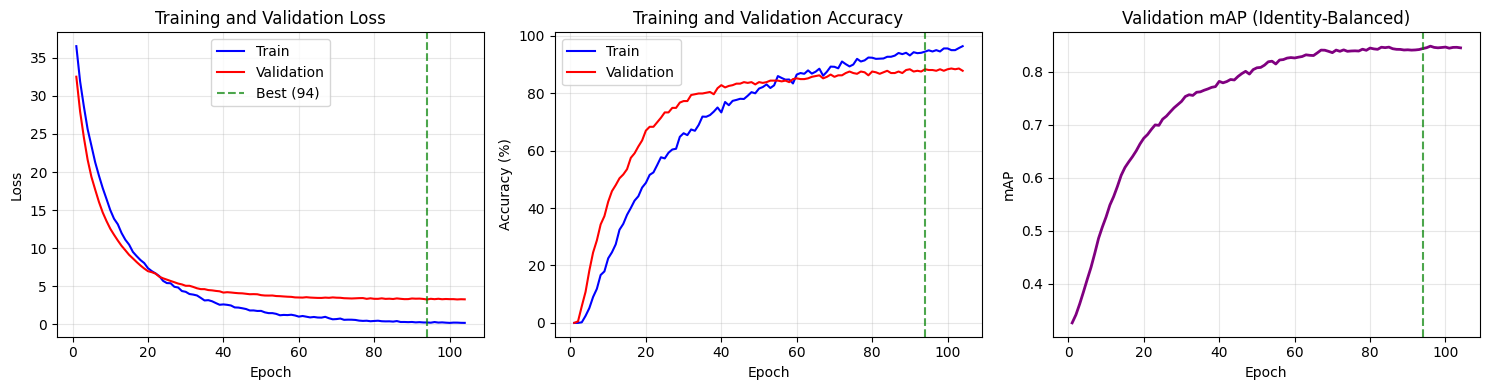

In [55]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_dino.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_dino": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2
  Val Loss: 3.2464
  Val mAP: 0.8433


In [ ]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(dino_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


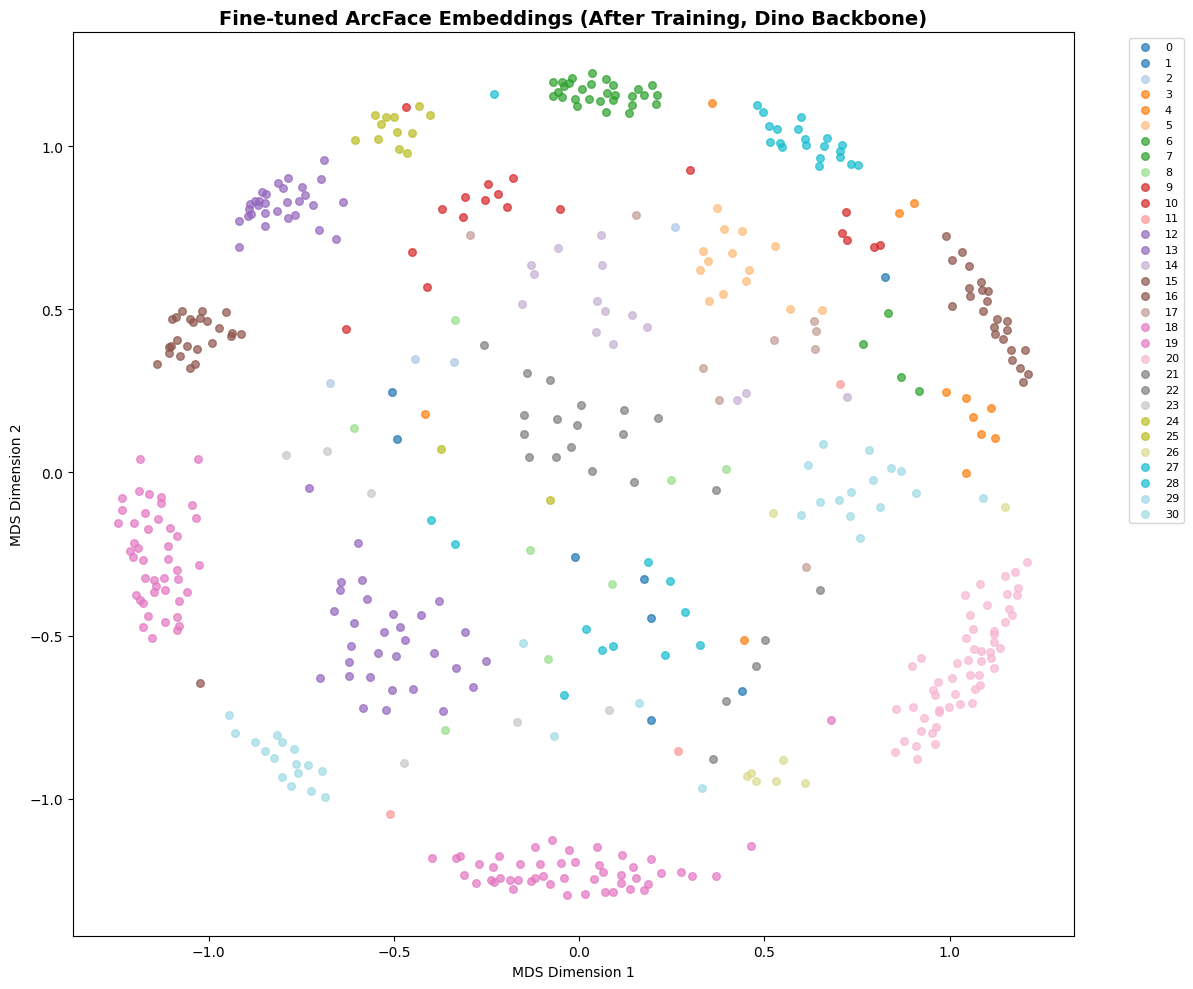

In [58]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, Dino Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "dino_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_dino": wandb.Image(fig_finetuned)})

In [59]:
del dino_dataset, dino_loader, dino_emb_train_dataset, dino_emb_val_dataset
del model, optimizer, scheduler, history
del dino, dino_preprocess, dino_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## EfficientNet

In [60]:
# Load EfficientNet model
print("Loading EfficientNet model...")
efficientnet = timm.create_model(
    config["efficientnet_model"],
    pretrained=True
)
efficientnet.eval()
efficientnet.to(device)
efficientnet.compile()

efficientnet_config = resolve_data_config({}, model=efficientnet)
efficientnet_preprocess = create_transform(**efficientnet_config, is_training=False)

efficientnet_num_params = sum(p.numel() for p in efficientnet.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {efficientnet_num_params:,}")
print(f"  Preprocessing: {efficientnet_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = efficientnet_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = efficientnet(dummy_input)
    efficientnet_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {efficientnet_dim}")

Loading EfficientNet model...
Model loaded successfully
  Parameters: 5,288,548
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.875, 'crop_mode': 'center'}
  Embedding dimension: 1000


In [ ]:
efficientnet_dataset = BlurImageDataset(image_paths, efficientnet_preprocess)
efficientnet_loader = DataLoader(
    efficientnet_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"EfficientNet DataLoader created with {len(efficientnet_loader)} batches")

EfficientNet DataLoader created with 60 batches


In [ ]:
efficientnet_cache_path = OUTPUT_PATH_SHARED / "efficientnet_blur_embeddings.npz"

efficientnet_embeddings = get_embeddings(
    efficientnet,
    efficientnet_cache_path,
    efficientnet_loader
)

Extracting embeddings for 60 images...


Extracting embeddings:   0%|          | 0/60 [00:00<?, ?it/s]

/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:312: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
Extracting embeddings: 100%|██████████| 60/60 [10:17<00:00, 10.29s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2/embeddings/efficientnet_embeddings.npz
Embeddings shape: (1895, 1000)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


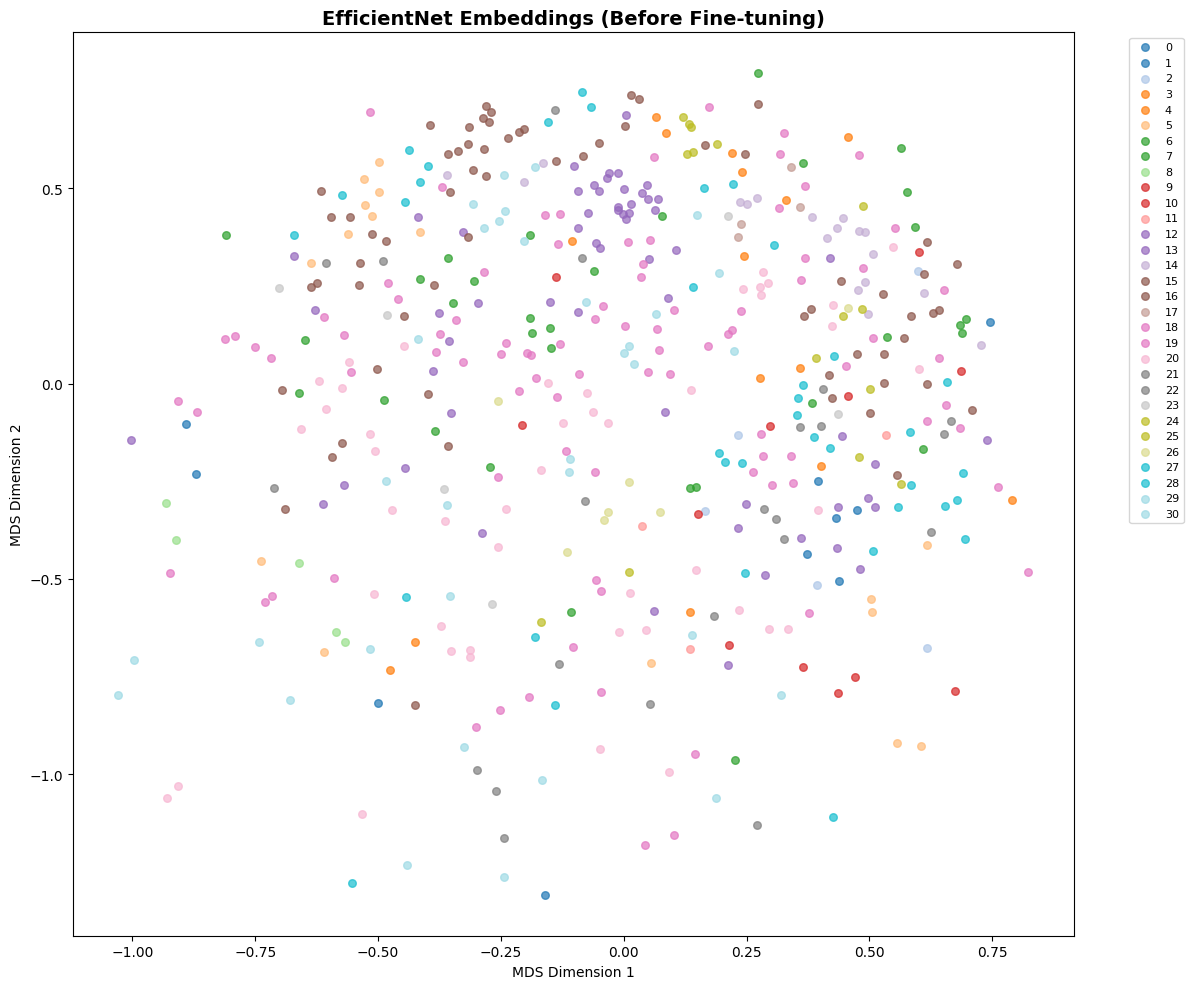

In [63]:
# Visualize EfficientNet embeddings
fig = visualize_embeddings_mds(
    efficientnet_embeddings,
    labels,
    "EfficientNet Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "efficientnet_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"efficientnet_embeddings_mds": wandb.Image(fig)})

In [ ]:
efficientnet_emb_train_dataset = EmbeddingDataset(
    efficientnet_embeddings[train_mask],
    train_labels
)

efficientnet_emb_val_dataset = EmbeddingDataset(
    efficientnet_embeddings[~train_mask],
    val_labels
)

efficientnet_emb_train_loader = create_deterministic_training_dataloader(
    efficientnet_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
)
efficientnet_emb_val_loader = DataLoader(
    efficientnet_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [ ]:
# Create model
model = EmbeddingProjection(
    input_dim=efficientnet_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

  Total parameters: 653,312


In [ ]:
# Setup training components
criterion = ArcFaceLoss(
    embedding_dim=efficientnet_dim,
    num_classes=num_classes,
    margin=config['arcface_margin'],
    scale=config['arcface_scale']
)

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

optimizer = torch.optim.AdamW(
    list(model.parameters(), criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_efficientnet_arcface.pth"
history, best_map, best_epoch = train_loop(
    model, 
    efficientnet_emb_train_loader, 
    efficientnet_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="efficientnet",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_efficientnet": best_map_duplicated,
    "best_epoch_efficientnet": best_epoch,
    "total_epochs_efficientnet": len(history['train_loss']),
})

table.append([
    "EfficientNet",
    best_map,
    best_epoch,
    efficientnet_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s, loss=39.0739, acc=0.0%]

  Train Loss: 37.3900 | Train Acc: 0.0%
  Val Loss:   33.6108 | Val Acc:   0.0%
  Val mAP:    0.3100 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 33.3478 | Train Acc: 0.0%
  Val Loss:   29.9252 | Val Acc:   0.0%
  Val mAP:    0.3215 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 30.3017 | Train Acc: 0.0%
  Val Loss:   26.8972 | Val Acc:   2.6%
  Val mAP:    0.3407 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.2435 | Train Acc: 94.4%
  Val Loss:   4.6701 | Val Acc:   82.6%
  Val mAP:    0.7986 | LR: 1.25e-05
  No improvement. Patience: 6/10

Epoch 135/200


  Train Loss: 0.2513 | Train Acc: 94.9%
  Val Loss:   4.7275 | Val Acc:   81.3%
  Val mAP:    0.7977 | LR: 1.25e-05
  No improvement. Patience: 7/10

Epoch 136/200


  Train Loss: 0.2047 | Train Acc: 94.3%
  Val Loss:   4.7017 | Val Acc:   81.8%
  Val mAP:    0.7991 | LR: 1.25e-05
  No improvement. Patience: 8/10

Epoch 137/200


  Train Loss: 0.2554 | Train Acc: 94.1%
  Val Loss:   4.6530 | Val Acc:   81.8%
  Val mAP:    0.7977 | LR: 1.25e-05
  No improvement. Patience: 9/10

Epoch 138/200


  Train Loss: 0.2285 | Train Acc: 95.1%
  Val Loss:   4.7493 | Val Acc:   81.8%
  Val mAP:    0.7962 | LR: 1.25e-05
  No improvement. Patience: 10/10

Early stopping triggered after 138 epochs

Training complete!
Best epoch: 128 (Val Loss: 4.5825, Val mAP: 0.8013)


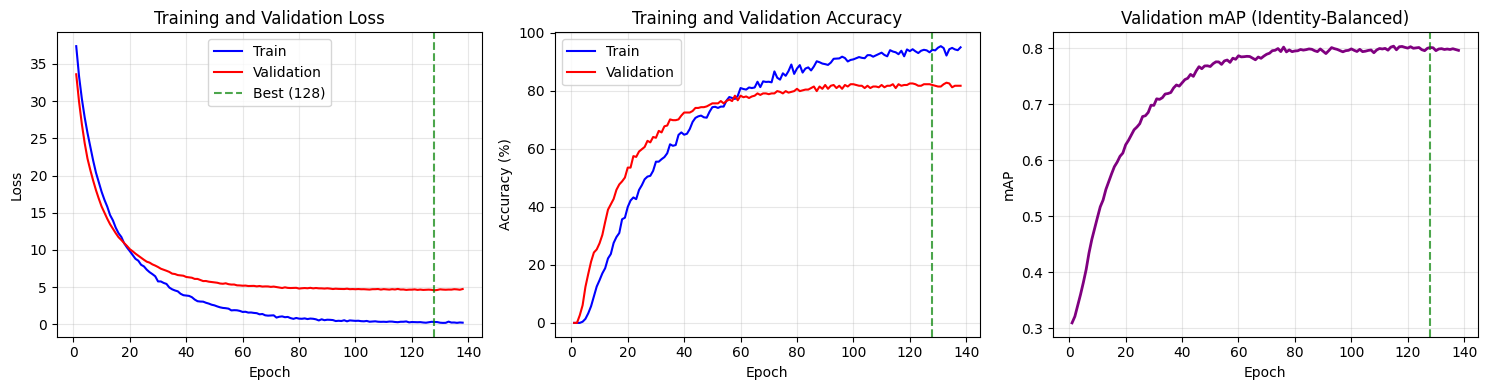

In [68]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_efficientnet": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2
  Val Loss: 4.5825
  Val mAP: 0.8013


In [ ]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(efficientnet_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


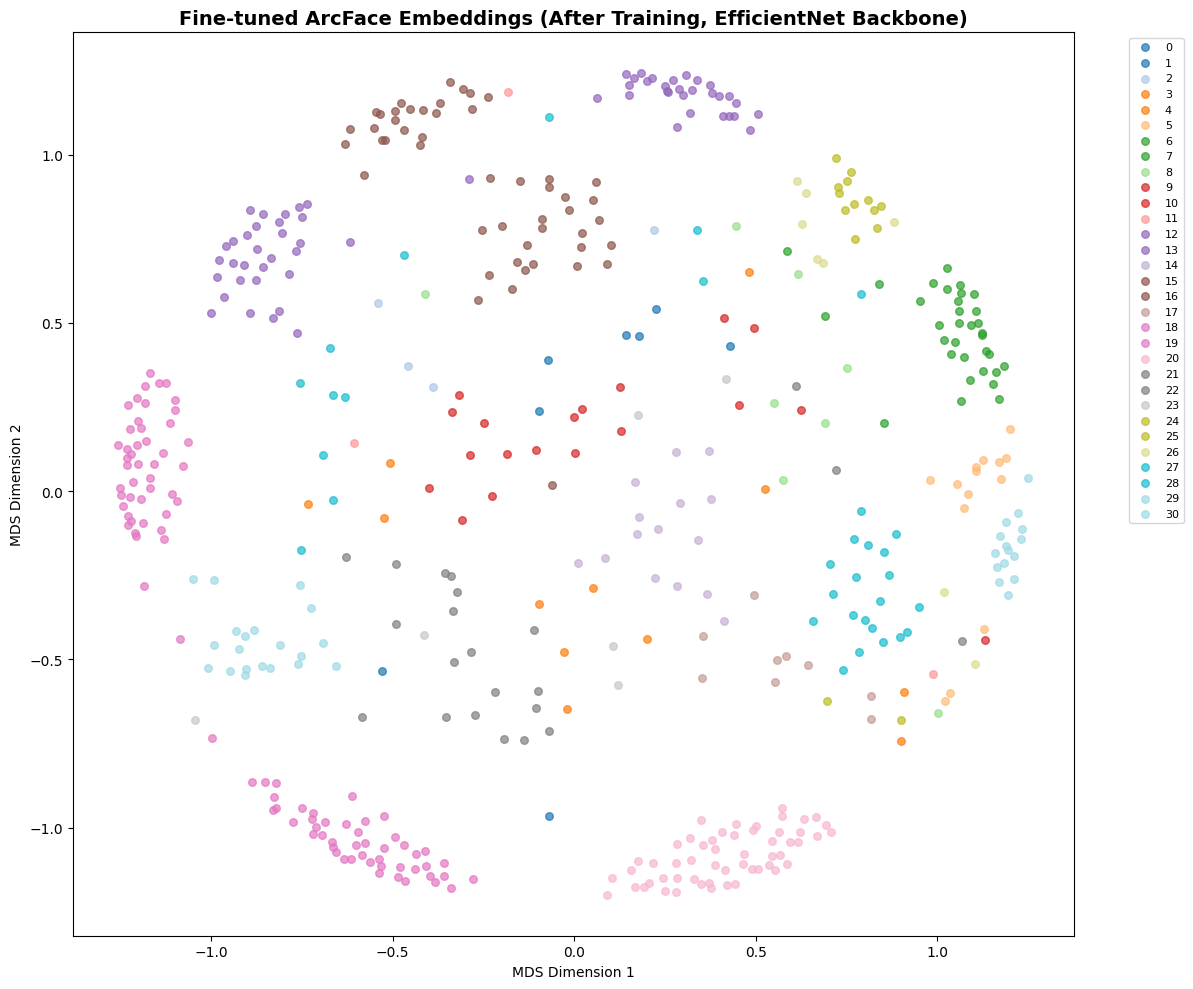

In [71]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, EfficientNet Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "efficientnet_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_efficientnet": wandb.Image(fig_finetuned)})

In [72]:
del efficientnet_dataset, efficientnet_loader, efficientnet_emb_train_dataset, efficientnet_emb_val_dataset
del model, optimizer, scheduler, history
del efficientnet, efficientnet_preprocess, efficientnet_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## ResNet18

In [73]:
# Load ResNet18 model
print("Loading ResNet18 model...")
resnet18 = timm.create_model(
    config["resnet18_model"],
    pretrained=True
)
resnet18.eval()
resnet18.to(device)
resnet18.compile()

resnet18_config = resolve_data_config({}, model=resnet18)
resnet18_preprocess = create_transform(**resnet18_config, is_training=False)

resnet18_num_params = sum(p.numel() for p in resnet18.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {resnet18_num_params:,}")
print(f"  Preprocessing: {resnet18_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = resnet18_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = resnet18(dummy_input)
    resnet18_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {resnet18_dim}")

Loading ResNet18 model...
Model loaded successfully
  Parameters: 11,689,512
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.95, 'crop_mode': 'center'}
  Embedding dimension: 1000


In [ ]:
resnet18_dataset = BlurImageDataset(image_paths, resnet18_preprocess)
resnet18_loader = DataLoader(
    resnet18_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

print(f"ResNet18 DataLoader created with {len(resnet18_loader)} batches")

ResNet18 DataLoader created with 60 batches


In [ ]:
resnet18_cache_path = OUTPUT_PATH_SHARED / "resnet18_blur_embeddings.npz"

resnet18_embeddings = get_embeddings(
    resnet18,
    resnet18_cache_path,
    resnet18_loader
)

Extracting embeddings for 60 images...


Extracting embeddings: 100%|██████████| 60/60 [10:59<00:00, 10.99s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2/embeddings/resnet18_embeddings.npz
Embeddings shape: (1895, 1000)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


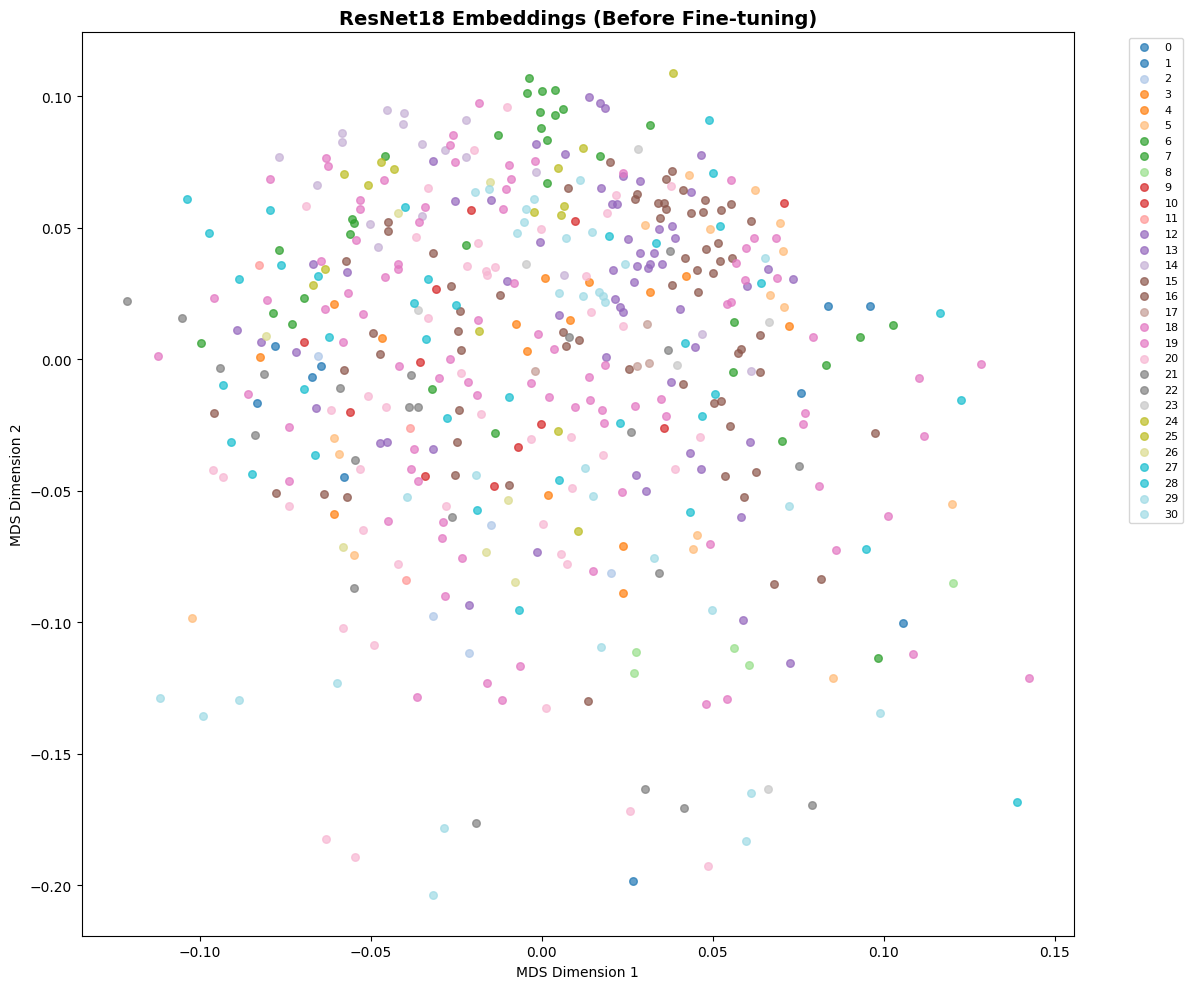

In [76]:
# Visualize ResNet18 embeddings
fig = visualize_embeddings_mds(
    resnet18_embeddings,
    labels,
    "ResNet18 Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "resnet18_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"resnet18_embeddings_mds": wandb.Image(fig)})

In [ ]:
resnet18_emb_train_dataset = EmbeddingDataset(
    resnet18_embeddings[train_mask],
    train_labels
)

resnet18_emb_val_dataset = EmbeddingDataset(
    resnet18_embeddings[~train_mask],
    val_labels
)

resnet18_emb_train_loader = create_deterministic_training_dataloader(
    resnet18_emb_train_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
)
resnet18_emb_val_loader = DataLoader(
    resnet18_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [ ]:
model = EmbeddingProjection(
    input_dim=resnet18_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

  Total parameters: 653,312


In [ ]:
# Setup training components
criterion = ArcFaceLoss(
    embedding_dim=megadescriptor_dim,
    num_classes=num_classes,
    margin=config['arcface_margin'],
    scale=config['arcface_scale']
)

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

optimizer = torch.optim.AdamW(
    list(model.parameters(), criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_resnet18_arcface.pth"
history, best_map, best_epoch = train_loop(
    model, 
    resnet18_emb_train_loader, 
    resnet18_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="resnet18",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_resnet18": best_map_duplicated,
    "best_epoch_resnet18": best_epoch,
    "total_epochs_resnet18": len(history['train_loss']),
})

table.append([
    "ResNet18",
    best_map,
    best_epoch,
    resnet18_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s, loss=37.0685, acc=0.0%]

  Train Loss: 36.8240 | Train Acc: 0.0%
  Val Loss:   36.8008 | Val Acc:   0.0%
  Val mAP:    0.2179 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 33.6812 | Train Acc: 0.0%
  Val Loss:   34.2523 | Val Acc:   0.0%
  Val mAP:    0.2279 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 31.7885 | Train Acc: 0.0%
  Val Loss:   31.9172 | Val Acc:   0.0%
  Val mAP:    0.2338 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 6.1138 | Train Acc: 55.1%
  Val Loss:   8.5346 | Val Acc:   60.4%
  Val mAP:    0.6661 | LR: 1.56e-06
  No improvement. Patience: 6/10

Epoch 136/200


  Train Loss: 6.0354 | Train Acc: 54.8%
  Val Loss:   8.5601 | Val Acc:   60.4%
  Val mAP:    0.6662 | LR: 1.56e-06
  No improvement. Patience: 7/10

Epoch 137/200


  Train Loss: 6.0377 | Train Acc: 54.5%
  Val Loss:   8.4733 | Val Acc:   60.9%
  Val mAP:    0.6669 | LR: 1.56e-06
  No improvement. Patience: 8/10

Epoch 138/200


  Train Loss: 5.9616 | Train Acc: 54.1%
  Val Loss:   8.4769 | Val Acc:   60.2%
  Val mAP:    0.6661 | LR: 1.56e-06
  No improvement. Patience: 9/10

Epoch 139/200


  Train Loss: 6.0736 | Train Acc: 53.0%
  Val Loss:   8.5085 | Val Acc:   60.7%
  Val mAP:    0.6664 | LR: 1.56e-06
  No improvement. Patience: 10/10

Early stopping triggered after 139 epochs

Training complete!
Best epoch: 129 (Val Loss: 8.4431, Val mAP: 0.6694)


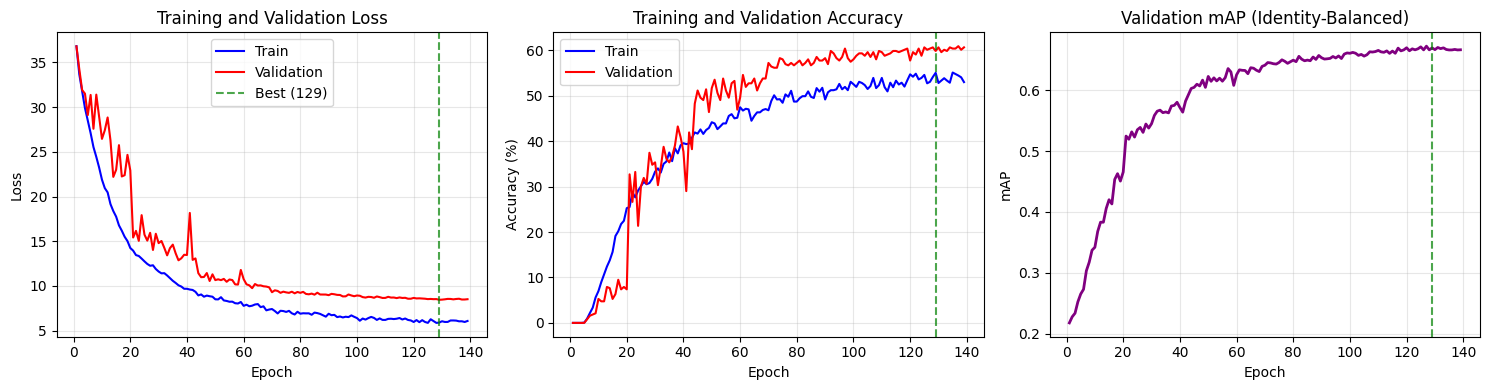

In [81]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_resnet18.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_resnet18": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone2
  Val Loss: 8.4431
  Val mAP: 0.6694


In [ ]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(resnet18_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


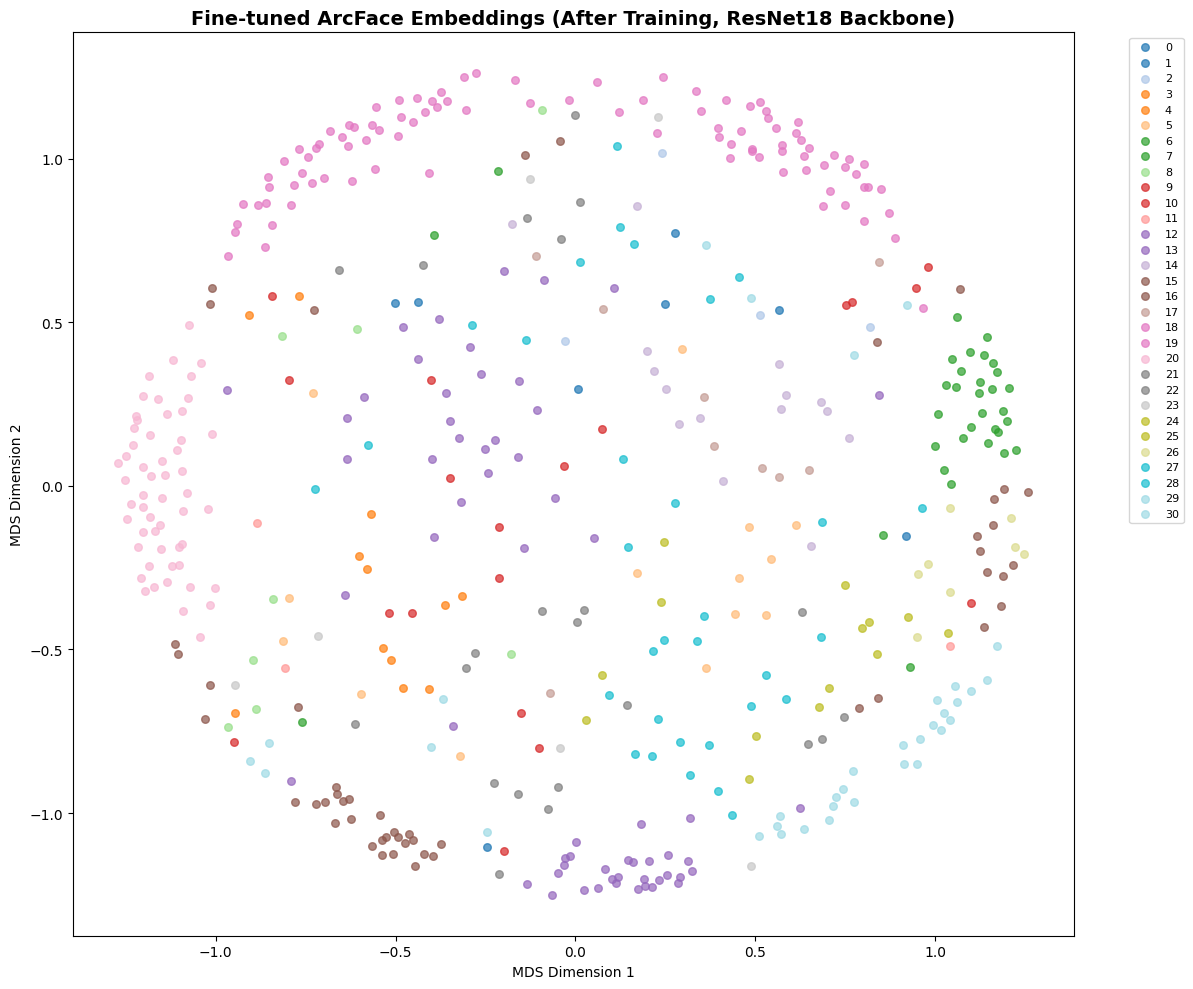

In [84]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, ResNet18 Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "resnet18_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_resnet18": wandb.Image(fig_finetuned)})

In [85]:
del resnet18_dataset, resnet18_loader, resnet18_emb_train_dataset, resnet18_emb_val_dataset
del model, optimizer, scheduler, history
del resnet18, resnet18_preprocess, resnet18_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## Summary

In [86]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+----------------+------------------+------------------+------------------+------------------+------------------+
| Backbone       |   MegaDescriptor |             CLIP |             Dino |     EfficientNet |         ResNet18 |
+================+==================+==================+==================+==================+==================+
| Best val_loss  |      4.4492      |      5.08588     |      3.24644     |      4.58246     |      8.44309     |
+----------------+------------------+------------------+------------------+------------------+------------------+
| Best val_mAP   |      0.790972    |      0.774152    |      0.843266    |      0.80129     |      0.669411    |
+----------------+------------------+------------------+------------------+------------------+------------------+
| Best epoch     |     78           |    123           |     94           |    128           |    129           |
+----------------+------------------+------------------+------------------+-------------

## Submission

In [87]:
embedding_model = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
embedding_model.eval()
embedding_model.to(device)
embedding_model.compile()

embedding_config = resolve_data_config({}, model=embedding_model)
embedding_preprocess = create_transform(**embedding_config, is_training=False)

print(f"Embedding model: {config['dinov3_model']}")
print(f"  Parameters: {sum(p.numel() for p in embedding_model.parameters()):,}")
print(f"  Preprocessing: {embedding_config}")

Embedding model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}


In [ ]:
arc_face_model = ArcFaceModel(
    input_dim=dino_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

checkpoint = torch.load(CHECKPOINT_PATH / "best_dino_arcface.pth", map_location=device, weights_only=False)
arc_face_model.load_state_dict(checkpoint['model_state_dict'])
arc_face_model.eval()

ArcFaceModel(
  (embedding_net): EmbeddingProjection(
    (network): Sequential(
      (0): Linear(in_features=768, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (arcface): ArcFaceLayer()
)

In [89]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(test_image_paths, embedding_preprocess),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    embedding_model,
    test_loader,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [01:58<00:00,  9.87s/it]

Test embeddings shape: (371, 768)


In [91]:
# Project through fine-tuned model
arc_face_model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = arc_face_model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [92]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 33607.74it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9951
  Mean: 0.0679
  Std: 0.1407


In [93]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.469534
1       1    0.019098
2       2    0.238367
3       3    0.239758
4       4    0.171039
5       5    0.115503
6       6    0.000000
7       7    0.076875
8       8    0.209241
9       9    0.008694

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [94]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/backbone2/submission.csv
File size: 1799.3 KB
